In [3]:
from enum import IntEnum
#from platform import win32_edition
from typing import Tuple, Optional, List
from gym import Env, spaces
from gym.utils import seeding
from gym.envs.registration import register

def register_env(id="WindyGridWorld-v0", entry_point="env:WindyGridWorldEnv") -> None:
    """Register custom gym environment so that we can use `gym.make()`

    In your main file, call this function before using `gym.make()` to use the Four Rooms environment.
        register_env()
        env = gym.make('WindyGridWorld-v0')

    There are a couple of ways to create Gym environments of the different variants of Windy Grid World.
    1. Create separate classes for each env and register each env separately.
    2. Create one class that has flags for each variant and register each env separately.

        Example:
        (Original)     register(id="WindyGridWorld-v0", entry_point="env:WindyGridWorldEnv")
        (King's moves) register(id="WindyGridWorldKings-v0", entry_point="env:WindyGridWorldEnv", **kwargs)

        The kwargs will be passed to the entry_point class.

    3. Create one class that has flags for each variant and register env once. You can then call gym.make using kwargs.

        Example:
        (Original)     gym.make("WindyGridWorld-v0")
        (King's moves) gym.make("WindyGridWorld-v0", **kwargs)

        The kwargs will be passed to the __init__() function.

    Choose whichever method you like.
    """
    register(id=id, entry_point=entry_point)

class Action_8(IntEnum):
    """Action extended"""

    LEFT = 0
    DOWN = 1
    RIGHT = 2
    UP = 3
    UP_LEFT = 4
    DOWN_LEFT = 5
    DOWN_RIGHT = 6
    UP_RIGHT = 7

def actions8_to_dxdy(action: Action_8) -> Tuple[int, int]:
    """
    Helper function to map action to changes in x and y coordinates
    Args:
        action (Action_ext): taken action
    Returns:
        dxdy (Tuple[int, int]): Change in x and y coordinates
    """
    mapping = {
        Action_8.LEFT: (-1, 0),
        Action_8.DOWN: (0, -1),
        Action_8.RIGHT: (1, 0),
        Action_8.UP: (0, 1),
        Action_8.UP_LEFT: (-1, 1),
        Action_8.DOWN_LEFT: (-1, -1),
        Action_8.DOWN_RIGHT: (1, -1),
        Action_8.UP_RIGHT: (1, 1),
    }
    return mapping[action]


class WindyStochasticGridWorldEnv(Env):
    def __init__(self):
        """Windy grid world gym environment
        This is the template for Q4d. You can use this class or modify it to create the variants for parts c and d.
        """

        # Altering the formulation of the winddy part slightly to use a np.random.choice to select a +1, +0, -1 to the wind value for that State
        
        # Grid dimensions (x, y)
        self.rows = 10
        self.cols = 7

        # Wind
        # TODO define self.wind as either a dict (keys would be states) or multidimensional array (states correspond to indices)
        self.wind = [[0]*self.rows]*self.cols
        for i in range(len(self.wind)):
            for j in range(len(self.wind[i])):
                if j == 3 or j == 4 or j == 5 or j == 8:
                    self.wind[i][j] = 1
                if j == 6 or j == 7:
                    self.wind[i][j] = 2

        self.action_space = spaces.Discrete(len(Action_8))
        self.observation_space = spaces.Tuple(
            (spaces.Discrete(self.rows), spaces.Discrete(self.cols))
        )

        # Set start_pos and goal_pos
        self.start_pos = (0, 3)
        self.goal_pos = (7, 3)
        self.agent_pos = None

    def seed(self, seed: Optional[int] = None) -> List[int]:
        """Fix seed of environment

        In order to make the environment completely reproducible, call this function and seed the action space as well.
            env = gym.make(...)
            env.seed(seed)
            env.action_space.seed(seed)

        This function does not need to be used for this assignment, it is given only for reference.
        """

        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def reset(self):
        self.agent_pos = self.start_pos
        return self.agent_pos

    def step(self, action: Action_8) -> Tuple[Tuple[int, int], float, bool, dict]:
        """Take one step in the environment.

        Takes in an action and returns the (next state, reward, done, info).
        See https://github.com/openai/gym/blob/master/gym/core.py#L42-L58 foand r more info.

        Args:
            action (Action): an action provided by the agent

        Returns:
            observation (object): agent's observation after taking one step in environment (this would be the next state s')
            reward (float) : reward for this transition
            done (bool): whether the episode has ended, in which case further step() calls will return undefined results
            info (dict): contains auxiliary diagnostic information (helpful for debugging, and sometimes learning). Not used in this assignment.
        """
         # Check if goal was reached
        #print(f"agent pos: {self.agent_pos}")
        if self.agent_pos == self.goal_pos:
            done = True
            reward = 0.0
        else:
            done = False
            reward = -1.0
            
        if not done:
            #print(f"change from action: {actions_to_dxdy(action)}")
            next_pos = tuple(map(lambda x,y: x + y, self.agent_pos, actions8_to_dxdy(action)))
            #print(f"next position: {next_pos}")
        
            #add the wind change to next pos
            #print(f"wind value: {self.wind[self.agent_pos[1]][self.agent_pos[0]]}")
            wind_dy = (0,self.wind[self.agent_pos[1]][self.agent_pos[0]])
            final_wind_dy = np.random.choice([wind_dy, (wind_dy+1), wind_dy-1])
            final_pos = tuple(map(lambda x,y: x+y, next_pos, final_wind_dy))
            #print(f"final position: {final_pos}")
        
            #check for grid boundaries 
            if final_pos[0] < 0 or final_pos[0] >= self.rows:
                final_pos = (self.agent_pos[0], final_pos[1])
            if final_pos[1] < 0 or final_pos[1] >= self.cols:
                final_pos = (final_pos[0], self.agent_pos[1])
            
            #print(f"final agent position: {self.agent_pos}")
        
        else:
            #print("restarting episode")
            final_pos = self.start_pos
    
        self.agent_pos = final_pos
        return self.agent_pos, reward, done, {}


In [4]:
register_env(id="WindyStochasticGridWorldEnv-v0", entry_point="env:WindyStochasticGridWorldEnv")

In [5]:
from gym import Env, spaces
from gym.utils import seeding
from gym.envs.registration import register
import gym

In [6]:
env = gym.make("WindyStochasticGridWorldEnv-v0")

In [7]:
env.reset()

(0, 3)

In [8]:
env.step(2)

((1, 3), -1.0, False, {})

In [9]:
env.step(2)

((2, 3), -1.0, False, {})

In [10]:
env.wind

[[0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0],
 [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]]

In [11]:
env.step(2)

((3, 3), -1.0, False, {})

In [12]:
env.step(2)

((4, 4), -1.0, False, {})

In [13]:
env.step(2)

((5, 5), -1.0, False, {})

In [14]:
env.step(2)

((6, 6), -1.0, False, {})

In [15]:
env.step(1)

((6, 6), -1.0, False, {})

In [16]:
env.step(1)

((6, 6), -1.0, False, {})

In [17]:
env.step(1)

((6, 6), -1.0, False, {})

In [18]:
env.step(0)

((5, 6), -1.0, False, {})

In [21]:
wind_dy = env.wind[6][5]

In [38]:
#testing stochastic wind values in sample state, possible values:
#wind value +1, -1, +0:
# = 0, 1, 2
import numpy as np
temps=[]
for i in range(100000):
    temps.append(np.random.choice([wind_dy, (wind_dy+1), wind_dy-1]))

In [39]:
#testing probability distribution of stochastic wind
#shown as percentages of total samples drawn
counts={}
for i in temps:
    if i not in counts:
        counts[i] = 1
    else:
        counts[i]+=1
for i in counts:
    counts[i]/=len(temps)
    counts[i]*=100
counts

{1: 33.146, 0: 33.522999999999996, 2: 33.331}

In [29]:
from math import exp
import gym
from typing import Optional
from collections import defaultdict
from typing import Tuple
import numpy as np

def egreedy_action(Q: defaultdict, state: Tuple[int, int], epsilon:float):
    greedy_action = np.random.choice([a for a in range(len(Q[state])) if Q[state][a] == max(Q[state])])
    exp_action = np.random.choice([0,1,2,3])
    action = np.random.choice([greedy_action, exp_action], p=[1-epsilon, epsilon])
    return action

def sarsa(env: gym.Env, num_steps: int, gamma: float, epsilon: float, step_size: float):
    """SARSA algorithm.

    Args:
        env (gym.Env): a Gym API compatible environment
        num_steps (int): Number of steps
        gamma (float): Discount factor of MDP
        epsilon (float): epsilon for epsilon greedy
        step_size (float): step size
    """
    # TODO
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    num_episodes = 0
    eps_perstep=[]
    #initial vals
    S = env.reset()
    #print(f"initisl state, from reset: {S}")
    A = egreedy_action(Q,S,epsilon)
    #print(f"initial action: {A}")
    for t in range(num_steps):
        #print(f"time step: {t}")
        S_prime, reward, done, _ = env.step(A)
        #print(f"Next State: {S_prime}, reward: {reward}, is done?: {done}")
        if done:
            num_episodes+=1
            #print(f"epsiode completed step: {t}")
            #print(f"number of episodes completed: {num_episodes}")
        eps_perstep.append(num_episodes)
        A_prime = egreedy_action(Q,S_prime,epsilon)
        #print(f"Next Action from e-greedy: {A_prime}")
        #print(f"old Q(S,A): {Q[S][A]}")
        Q[S][A] = Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime] - Q[S][A])
        #print(f"Update to Q(S,A): {Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime])}")
        S=S_prime
        A=A_prime
    return eps_perstep, Q

def q_learning(
    env: gym.Env,
    num_steps: int,
    gamma: float,
    epsilon: float,
    step_size: float,
):
    """Q-learning

    Args:
        env (gym.Env): a Gym API compatible environment
        num_steps (int): Number of steps
        gamma (float): Discount factor of MDP
        epsilon (float): epsilon for epsilon greedy
        step_size (float): step size
    """
    # TODO
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    num_episodes = 0
    eps_perstep = []
    #initial vals
    S = env.reset()
    for t in range(num_steps):
        A = egreedy_action(Q,S,epsilon)
        S_prime, reward, done, _ = env.step(A)
        if done:
            num_episodes+=1
            #print(f"epsiode completed step: {t}")
            #print(f"number of episodes completed: {num_episodes}")
        eps_perstep.append(num_episodes)
        A_prime = np.random.choice([a for a in range(len(Q[S_prime])) if Q[S_prime][a] == max(Q[S_prime])])
        Q[S][A] = Q[S][A] + step_size*(reward + gamma*Q[S_prime][A_prime] - Q[S][A])
        S=S_prime
    return eps_perstep, Q

In [40]:
num_steps=10000
gamma=1
epsilon=0.1
step_size=0.5

In [41]:
eps_p_step_sarsa,Q = sarsa(env,num_steps,gamma,epsilon,step_size)
eps_p_step_qlearn, Q = q_learning(env,num_steps,gamma,epsilon,step_size)

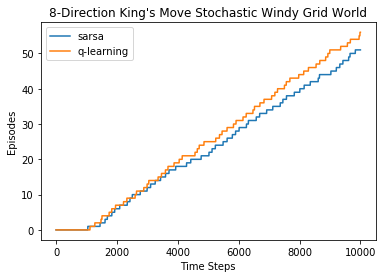

In [42]:
import matplotlib.pyplot as plt
plt.plot(np.arange(0,num_steps,1),eps_p_step_sarsa)
plt.plot(np.arange(0,num_steps,1),eps_p_step_qlearn)
plt.legend(['sarsa', 'q-learning'], loc='upper left')
plt.xlabel('Time Steps')
plt.ylabel('Episodes')
plt.title("8-Direction King's Move Stochastic Windy Grid World")
plt.savefig('q4_d_StochasticKingsmoveWindyGridWorld_d8mov.pdf')
plt.show()